Bert base cased fine-tune on multiclass classification for twitter tweets

In [1]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/laxmimerit/All-CSV-ML-Data-Files-Download/master/twitter_multi_class_sentiment.csv")


In [25]:
df['text'][0]

'i didnt feel humiliated'

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        16000 non-null  object
 1   label       16000 non-null  int64 
 2   label_name  16000 non-null  object
dtypes: int64(1), object(2)
memory usage: 375.1+ KB


In [4]:
df['label'].value_counts()

,count
label,
1,5362
0,4666
3,2159
4,1937
2,1304
5,572


Text to tokens conversion

In [5]:
from transformers import AutoTokenizer

model_ckpt = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

len(tokenizer.vocab), tokenizer.vocab_size, tokenizer.model_max_length

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


(30522, 30522, 512)

DataLoader and Train test split

In [6]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.3, stratify=df['label_name'])

test, eval = train_test_split(test, test_size=1/3, stratify=test['label_name'])

train.shape, test.shape, eval.shape

((11200, 3), (3200, 3), (1600, 3))

In [7]:
from datasets import Dataset, DatasetDict

dataset=DatasetDict({
    "train": Dataset.from_pandas(train, preserve_index=False),
    "test": Dataset.from_pandas(test, preserve_index=False),
    "eval": Dataset.from_pandas(eval, preserve_index=False)
})

dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_name'],
        num_rows: 11200
    })
    test: Dataset({
        features: ['text', 'label', 'label_name'],
        num_rows: 3200
    })
    eval: Dataset({
        features: ['text', 'label', 'label_name'],
        num_rows: 1600
    })
})

In [8]:
dataset['train'][0], dataset['train'][0]

({'text': 'i am feeling brave we will go somewhere further afield like a walk in the woodlands around a farm to the beach or some other full day activity',
  'label': 1,
  'label_name': 'joy'},
 {'text': 'i am feeling brave we will go somewhere further afield like a walk in the woodlands around a farm to the beach or some other full day activity',
  'label': 1,
  'label_name': 'joy'})

In [9]:
def tokenize(batch):
    temp = tokenizer(batch['text'], padding=True, truncation=True)
    return temp

dataset_encoded = dataset.map(tokenize, batched=True, batch_size=None)

Map:   0%|          | 0/11200 [00:00<?, ? examples/s]

Map:   0%|          | 0/3200 [00:00<?, ? examples/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

In [10]:
# we need label2id and id2label for the model to understand the labels
label2id = {v:k for k,v in enumerate(df['label_name'].unique())}
id2label = {v:k for k,v in label2id.items()}

label2id, id2label

({'sadness': 0, 'anger': 1, 'love': 2, 'surprise': 3, 'fear': 4, 'joy': 5},
 {0: 'sadness', 1: 'anger', 2: 'love', 3: 'surprise', 4: 'fear', 5: 'joy'})

Model building and training

In [11]:
from transformers import AutoModel
import torch

model = AutoModel.from_pretrained(model_ckpt)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [12]:
model.config.id2label
model.config

BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}

In [13]:
from transformers import AutoModelForSequenceClassification, AutoConfig

num_labels = len(label2id)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
config = AutoConfig.from_pretrained(model_ckpt, num_labels=num_labels, id2label=id2label, label2id=label2id)
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, config=config).to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [14]:
model.config

BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "sadness",
    "1": "anger",
    "2": "love",
    "3": "surprise",
    "4": "fear",
    "5": "joy"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "label2id": {
    "anger": 1,
    "fear": 4,
    "joy": 5,
    "love": 2,
    "sadness": 0,
    "surprise": 3
  },
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 

In [15]:
from transformers import Trainer, TrainingArguments

batch_size = 64
training_dir = "/Users/pi/projects/my_finetuning/Learning_traditional_ML/bert_base_train_dir"
training_args = TrainingArguments(output_dir=training_dir,
                                  num_train_epochs = 2,
                                  learning_rate = 2e-5,
                                  per_device_train_batch_size = batch_size,
                                  per_device_eval_batch_size = batch_size,
                                  weight_decay = 0.01,
                                  disable_tqdm = False
)

In [16]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='weighted')
    return {
        'accuracy': acc,
        'f1': f1
    }

Build Model and Trainer

In [17]:
trainer = Trainer(model=model,
                  args=training_args,
                  compute_metrics=compute_metrics,
                  train_dataset=dataset_encoded['train'],
                  eval_dataset=dataset_encoded['eval'])

trainer.train()

Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=350, training_loss=0.7216011701311384, metrics={'train_runtime': 292.037, 'train_samples_per_second': 76.703, 'train_steps_per_second': 1.198, 'total_flos': 897898722739200.0, 'train_loss': 0.7216011701311384, 'epoch': 2.0})

In [18]:
# evaluation

preds_output = trainer.predict(dataset_encoded['test'])
preds_output.metrics

{'test_loss': 0.2895931601524353,
 'test_accuracy': 0.904375,
 'test_f1': 0.9037878298310575,
 'test_runtime': 12.0478,
 'test_samples_per_second': 265.609,
 'test_steps_per_second': 4.15}

In [19]:
import numpy as np
y_pred = np.argmax(preds_output.predictions, axis=1)
y_true = dataset_encoded['test'][:]['label']

In [20]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.95      0.94       933
           1       0.93      0.92      0.93      1072
           2       0.80      0.79      0.79       261
           3       0.88      0.91      0.90       432
           4       0.88      0.86      0.87       387
           5       0.86      0.72      0.79       115

    accuracy                           0.90      3200
   macro avg       0.88      0.86      0.87      3200
weighted avg       0.90      0.90      0.90      3200



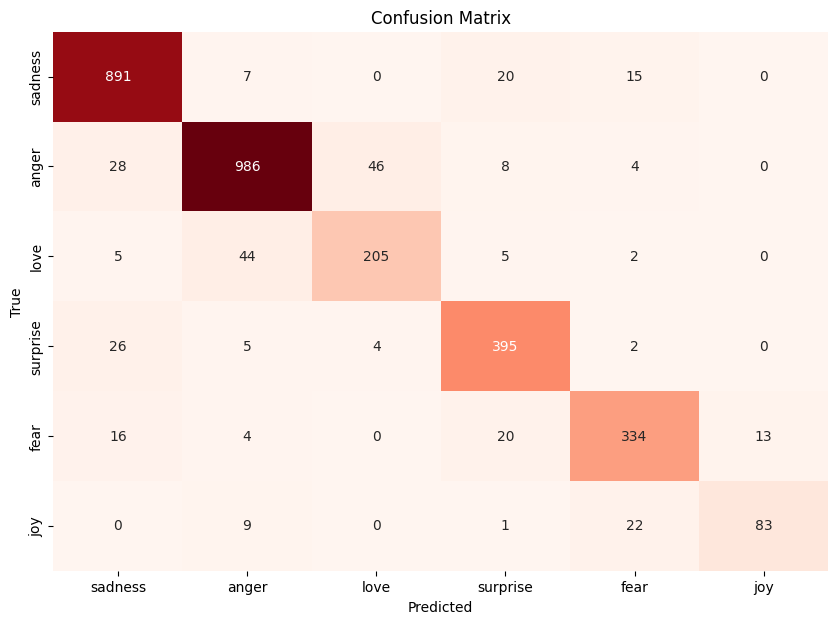

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, xticklabels=label2id.keys(), yticklabels=label2id.keys(), fmt='d', cbar=False, cmap='Reds')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [33]:
def get_predictions(text):
    toknized_text = tokenizer(text, return_tensors='pt', padding=True, truncation=True).to(device)
    with torch.no_grad():
        output = model(**toknized_text)
    pred_label_id = output.logits.argmax(-1).item()
    return id2label[pred_label_id]

get_predictions("i hate you")

'surprise'

In [23]:
trainer.save_model("/Users/pi/projects/my_finetuning/Learning_traditional_ML/bert_base_finetuned")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [34]:
from transformers import pipeline
classifier = pipeline('text-classification', model= "/Users/pi/projects/my_finetuning/Learning_traditional_ML/bert_base_finetuned")

# classifier(['I am so happy today!', "I am feeling sad", "I hate you"])

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]